# Getting Started

## Install & Import NetworkX

We begin by installing the latest `networkx` package (for network analysis), and import the `matplotlib` package (for graph visualisation):

In [25]:
# Install the latest version of scipy and networkx
!pip install --upgrade scipy networkx

# Import the NetworkX library for network analysis
import networkx as nx

# Import Matplotlib for graph visualization
import matplotlib.pyplot as plt

# Import NumPy for numerical operations
import numpy as np

We start by importing the following libraries.

In [26]:
# Import NetworkX for graph operations
import networkx as nx

# Import Matplotlib for graph visualisation
import matplotlib.pyplot as plt

# Import NumPy for numerical computations
import numpy as np

First, we create an empty undirected graph `G`. Using `G.add_edges_from()` method, we add edges to the graph `G`.

In [27]:
# Add a line of code to create an empty undirected graph using NetworkX
G = nx.Graph()

# Add a line of code to insert the six edges (in Figure 1) to the graph G
G = nx.erdos_renyi_graph(n=10, p=0.3)

Next, we display the adjacency matrix `A` and Laplacian matrix `L` of the graph using NetworkX.

In [28]:
# Add a line of code to get the adjacency matrix (A) of the graph (G)
A = nx.adjacency_matrix(G).toarray()

# Add a line of code to get the Laplacian matrix (L) of the graph (G)
L = nx.laplacian_matrix(G).toarray()

# Display the adjacency matrix
print("\nAdjacency Matrix:")
print(A)

# Display the Laplacian matrix
print("\nLaplacian Matrix:")
print(L)


Adjacency Matrix:
[[0 1 0 1 1 1 1 0 1 0]
 [1 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 1 1 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 1 1]
 [1 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 0 0 0 0]
 [1 0 0 1 0 1 0 0 0 0]
 [0 1 0 1 1 1 0 0 0 0]]

Laplacian Matrix:
[[ 6 -1  0 -1 -1 -1 -1  0 -1  0]
 [-1  3  0  0  0  0  0 -1  0 -1]
 [ 0  0  0  0  0  0  0  0  0  0]
 [-1  0  0  4  0  0  0 -1 -1 -1]
 [-1  0  0  0  2  0  0  0  0 -1]
 [-1  0  0  0  0  4  0 -1 -1 -1]
 [-1  0  0  0  0  0  1  0  0  0]
 [ 0 -1  0 -1  0 -1  0  3  0  0]
 [-1  0  0 -1  0 -1  0  0  3  0]
 [ 0 -1  0 -1 -1 -1  0  0  0  4]]


Next, we calculate the degree for all nodes and scale the node sizes based on their degree multiplying by `300` for better visualization.

In [29]:
# TODO: Add a line of code to create a list of degrees for all nodes using list comprehension
node_degrees = [G.degree(n) for n in G.nodes()]
print("\nNode Degrees:")
print(node_degrees)

# TODO: Add a line of code to create a list of node sizes based on degree multiplying by 300 for better visibility
node_sizes = [G.degree(n) * 300 for n in G.nodes()]
print("\nNode Sizes:")
print(node_sizes)


Node Degrees:
[6, 3, 0, 4, 2, 4, 1, 3, 3, 4]

Node Sizes:
[1800, 900, 0, 1200, 600, 1200, 300, 900, 900, 1200]


Finally, we draw the graph, with nodes labeled and sized based on their degree (`node_sizes`)

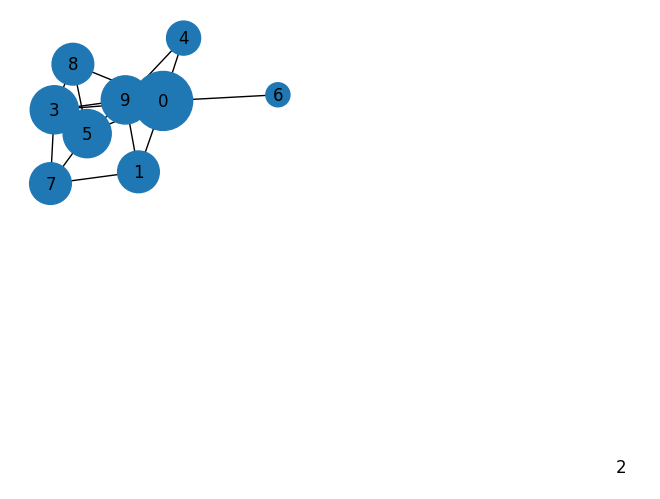

In [30]:
# Add a line of code to draw the graph with the computed node sizes (node_sizes)
nx.draw(G, with_labels=True, node_size=node_sizes)

## Exercise 2a: Fixed-Point Iteration

Write a piece of code that can iteratively compute the PageRank vector $\vec{p}$ for a given graph $G$ as follows:

$$
\vec{p}^{(k+1)} = cW \vec{p}^{(k)} + \tfrac{1-c}{|V|} \vec{1} \quad (k=0,1,2,\cdots, K) \quad \text{with} \quad \vec{p}^{(0)}= \tfrac{1}{|V|} \vec{1} \tag{3}  
$$


Set the total number of iterations $K=100$, and the damping factor $c=0.8$.

In [31]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

kmax = 100  # total number of iterations
c = 0.8     # damping factor

G = nx.DiGraph([(1,2), (1,3), (3,2), (4,3), (5,2)])   # digraph G
A = nx.adjacency_matrix(G)   # get adjacency matrix A
print(f'A = \n {A.todense()}')

# Step 1. Preprocessing:  Replace each zero row of A with a row of all 1s.
#         NB: This preprocessing step is used to avoid a division-by-zero problem in Eq.(1) when |O(y)|=0.

#     1a) get the number of nodes |V| in G
#     1b) find zero-row index
#     1c) replace each zero row of A with a row of all 1s
n = A.shape[0]
v = (np.diff(A.indptr)==0).astype(int)
A = A + np.outer(v, np.ones(n))
print(f'\nRefined A = \n {A}')

# Step 2. Get matrix W from the preprocessed matrix A such that W = column-norm(A^T)

W = A.T / A.sum(axis=1)

print(f'\nW = \n {W}')

# Step 3. According to Eq.(3), iteratively compute PageRank vector p for K iterations (K=100)

p = np.ones(n)/n
for k in range(kmax):
    p = c* (W @ p) + (1-c)/n*np.ones(n)

print(f'\nPageRank vector p = \n {p}')


A = 
 [[0 1 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]]

Refined A = 
 [[0. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]

W = 
 [[0.  0.2 0.  0.  0. ]
 [0.5 0.2 1.  0.  1. ]
 [0.5 0.2 0.  1.  0. ]
 [0.  0.2 0.  0.  0. ]
 [0.  0.2 0.  0.  0. ]]

PageRank vector p = 
 [0.10917031 0.43231441 0.24017467 0.10917031 0.10917031]


In [32]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

kmax = 100  # total number of iterations
c = 0.8     # damping factor

G = nx.DiGraph([(1,2), (1,3), (3,2), (4,3), (5,2)])   # digraph G
A = nx.adjacency_matrix(G)   # get adjacency matrix A
print(f'A = \n {A.todense()}')

# Step 1. Preprocessing:  Replace each zero row of A with a row of all 1s.
#         NB: This preprocessing step is used to avoid a division-by-zero problem in Eq.(1) when |O(y)|=0.

n = A.shape[0]
v = (np.diff(A.indptr)==0).astype(int)
A = A + np.outer(v, np.ones(n))
print(f'\nRefined A = \n {A}')

# Step 2. Get matrix W from the preprocessed matrix A such that W = column-norm(A^T)

W = A.T / A.sum(axis=1)
print(f'\nW = \n {W}')

# Step 3. According to Eq.(3), iteratively compute PageRank vector p for K iterations (K=100)

p = np.ones(n)/n
for k in range(kmax):
    p = c* (W @ p) + (1-c)/n*np.ones(n)

print(f'\nPageRank vector p = \n {p}')


A = 
 [[0 1 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]]

Refined A = 
 [[0. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]

W = 
 [[0.  0.2 0.  0.  0. ]
 [0.5 0.2 1.  0.  1. ]
 [0.5 0.2 0.  1.  0. ]
 [0.  0.2 0.  0.  0. ]
 [0.  0.2 0.  0.  0. ]]

PageRank vector p = 
 [0.10917031 0.43231441 0.24017467 0.10917031 0.10917031]


## Exercise 2b: Matrix Inverse Method

Write a piece of code that employs the non-iterative matrix inverse method to compute the PageRank vector $\vec{p}$ for a given graph $G$ as follows:

$$
\vec{p} =  \tfrac{1-c}{|V|} (I-cW)^{-1} \vec{1} \tag{4}  
$$

where $I$ is the identity matrix. Set the damping factor $c=0.8$.

In [33]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

c = 0.8     # damping factor

G = nx.DiGraph([(1,2), (1,3), (3,2), (4,3), (5,2)])   # digraph G
A = nx.adjacency_matrix(G)   # get adjacency matrix A
print(f'A = \n {A.todense()}')

# Step 1. Preprocessing:  Replace each zero row of A with a row of all 1s.
#         NB: This preprocessing step is used to avoid a division-by-zero problem in Eq.(1) when |O(y)|=0.

n = A.shape[0]
v = (np.diff(A.indptr)==0).astype(int)
A = A + np.outer(v, np.ones(n))

print(f'\nRefined A = \n {A}')

# Step 2. Get matrix W from the preprocessed matrix A such that W = column-norm(A^T)

W = A.T / A.sum(axis=1)
print(f'\nW = \n {W}')

# Step 3. According to Eq.(4), compute PageRank vector p

I = np.eye(n)
p = (1-c)/n * np.linalg.inv(I-c*W) @ np.ones(n)

print(f'\nPageRank vector p = \n {p}')

A = 
 [[0 1 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]]

Refined A = 
 [[0. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]

W = 
 [[0.  0.2 0.  0.  0. ]
 [0.5 0.2 1.  0.  1. ]
 [0.5 0.2 0.  1.  0. ]
 [0.  0.2 0.  0.  0. ]
 [0.  0.2 0.  0.  0. ]]

PageRank vector p = 
 [0.10917031 0.43231441 0.24017467 0.10917031 0.10917031]


## Exercise 3c: Dominant Eigenvector Method

Write a piece of code that computes the PageRank vector $\vec{p}$ for a given graph $G$ by finding the dominant eigenvector of the Google matrix $G$ associated with the eigenvalue 1 such that

$$
\vec{p} = G \vec{p} \quad \text{where} \quad G = cW + \tfrac{1-c}{|V|} \vec{1} \cdot \vec{1}^T  \tag{5}  
$$

Set the damping factor $c=0.8$. Note that $\vec{1}$ denotes a column vector of length $|V|$.

In [34]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

c = 0.8     # damping factor

G = nx.DiGraph([(1,2), (1,3), (3,2), (4,3), (5,2)])   # digraph G
A = nx.adjacency_matrix(G)   # get adjacency matrix A
print(f'A = \n {A.todense()}')

# Step 1. Preprocessing:  Replace each zero row of A with a row of all 1s.
#         NB: This preprocessing step is used to avoid a division-by-zero problem in Eq.(1) when |O(y)|=0.

n = A.shape[0]
v = (np.diff(A.indptr)==0).astype(int)
A = A + np.outer(v, np.ones(n))

print(f'\nRefined A = \n {A}')

# Step 2. Get matrix W from the preprocessed matrix A such that W = column-norm(A^T)

W = A.T / A.sum(axis=1)

print(f'\nW = \n {W}')

# Step 3. According to Eq.(5), compute the Google Matrix G

G = (c * W) + (1-c) / n * np.ones([n,n])

print(f'\nG = \n {G}')

# Step 4. Find the dominant eigenvector p of G associated with the largest eigenvalue 1

u, v = np.linalg.eig(G)
p = v[:,np.argmax(abs(u))]

# Step 5. Normalise the vector p s.t. the sum of all its elements is 1

p = p = abs(p/p.sum())

print(f'\nPageRank vector p = \n {p}')

A = 
 [[0 1 1 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]]

Refined A = 
 [[0. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0.]]

W = 
 [[0.  0.2 0.  0.  0. ]
 [0.5 0.2 1.  0.  1. ]
 [0.5 0.2 0.  1.  0. ]
 [0.  0.2 0.  0.  0. ]
 [0.  0.2 0.  0.  0. ]]

G = 
 [[0.04 0.2  0.04 0.04 0.04]
 [0.44 0.2  0.84 0.04 0.84]
 [0.44 0.2  0.04 0.84 0.04]
 [0.04 0.2  0.04 0.04 0.04]
 [0.04 0.2  0.04 0.04 0.04]]

PageRank vector p = 
 [0.10917031 0.43231441 0.24017467 0.10917031 0.10917031]
